In [1]:
%load_ext autoreload
%autoreload 2

In [23]:
import numpy as np
import torch
from models.linear_probes import linear_probe, linear_probe_tuned,linear_probe_tuned_smote
from models.feature_generation import build_feature_bank, extract_encoder, extract_feature,pool_features
from preprocessing.dataset import PipistrelleDataset
from evaluation.metrics import compute_cv_stats,plot_model_comparison,label_confusion
import pandas as pd
from sklearn.metrics import average_precision_score
from evaluation.metrics import compute_metrics,compile_results,generate_metrics_table2
from evaluation.metrics import plot_comprehensive_calibration,plot_loss_curves,plot_comprehensive_results3
from models.MLP_balancing import balancing_mlp,balancing_mlp_val
import pickle
from pathlib import Path
import os
from models.mlsmote import get_minority_instace,MLSMOTE
from tabulate import tabulate

In [3]:
dir = Path(os.getcwd()).resolve().parent 
path = str(dir / "models" / "features")
X_eff0 = np.load(path + "\\X_features2_not_normalized.npy")
X_NLM = np.load(path + "\\X_features_NLM.npy")
X_per2 = np.load(path + "\\perch_features.npz")['features']
y = np.load(path + "\\Y_labels2_not_normalized.npy")
label_names = ['Type A', 'Type B', 'Type C', 'Type D', 'Echo']

In [4]:
X_eff0_pooled = pool_features(X_eff0, windows=False, window_pooled=True, method='mean',encoder="effnetb0")
X_NLM_pooled = pool_features(X_NLM, windows=False, window_pooled=True, method='mean',encoder="NLM_BEATs")
X_per2_pooled = X_per2

In [20]:
per2_balancing_results2 = balancing_mlp(X_per2_pooled, y, n_split_out=5,n_split_in=5, num_trials=5,random_state=42)

Starting Trial 1/5 with random_state=42...
  Tuning and evaluating model: MLP_Baseline
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: MLP_ClassWeights
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: MLP_FocalLoss
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: MLP_Oversampled
    Evaluating fold 1/5
Final counts: [189 189 202 189 364]
    Evaluating fold 2/5
Final counts: [189 189 230 189 390]
    Evaluating fold 3/5
Final counts: [189 189 216 189 409]
    Evaluating fold 4/5
Final counts: [189 189 238 189 378]
    Evaluating fold 5/5
Final counts: [188 188 195 188 372]
Starting Trial 2/5 with random_state=43...
  Tuning and evaluating model: MLP_Baseline
    Evaluating fold 1/5
  

In [31]:
label_names = ['Type A', 'Type B', 'Type C', 'Type D','Echo']

per2_compiled_balanced = compile_results(per2_balancing_results2,label_names=label_names,encoder="per2")

df = pd.DataFrame(generate_metrics_table2(per2_compiled_balanced,label_names=label_names)[0])
print(tabulate(df, headers='keys', tablefmt='psql'))

+----+-----------------------+---------------+-------------------+-----------------+---------------+
|    | Model                 | Macro-AUC     | Macro-AP (cmAP)   | Brier Score ↓   | Log-Loss ↓    |
|----+-----------------------+---------------+-------------------+-----------------+---------------|
|  0 | per2 MLP_ClassWeights | 0.947 ± 0.005 | 0.876 ± 0.012     | 0.063 ± 0.004   | 0.336 ± 0.024 |
|  1 | per2 MLP_FocalLoss    | 0.945 ± 0.006 | 0.878 ± 0.012     | 0.058 ± 0.003   | 0.244 ± 0.016 |
|  2 | per2 MLP_Oversampled  | 0.943 ± 0.005 | 0.872 ± 0.012     | 0.067 ± 0.005   | 0.454 ± 0.030 |
|  3 | per2 MLP_Baseline     | 0.944 ± 0.008 | 0.874 ± 0.009     | 0.061 ± 0.004   | 0.356 ± 0.023 |
+----+-----------------------+---------------+-------------------+-----------------+---------------+


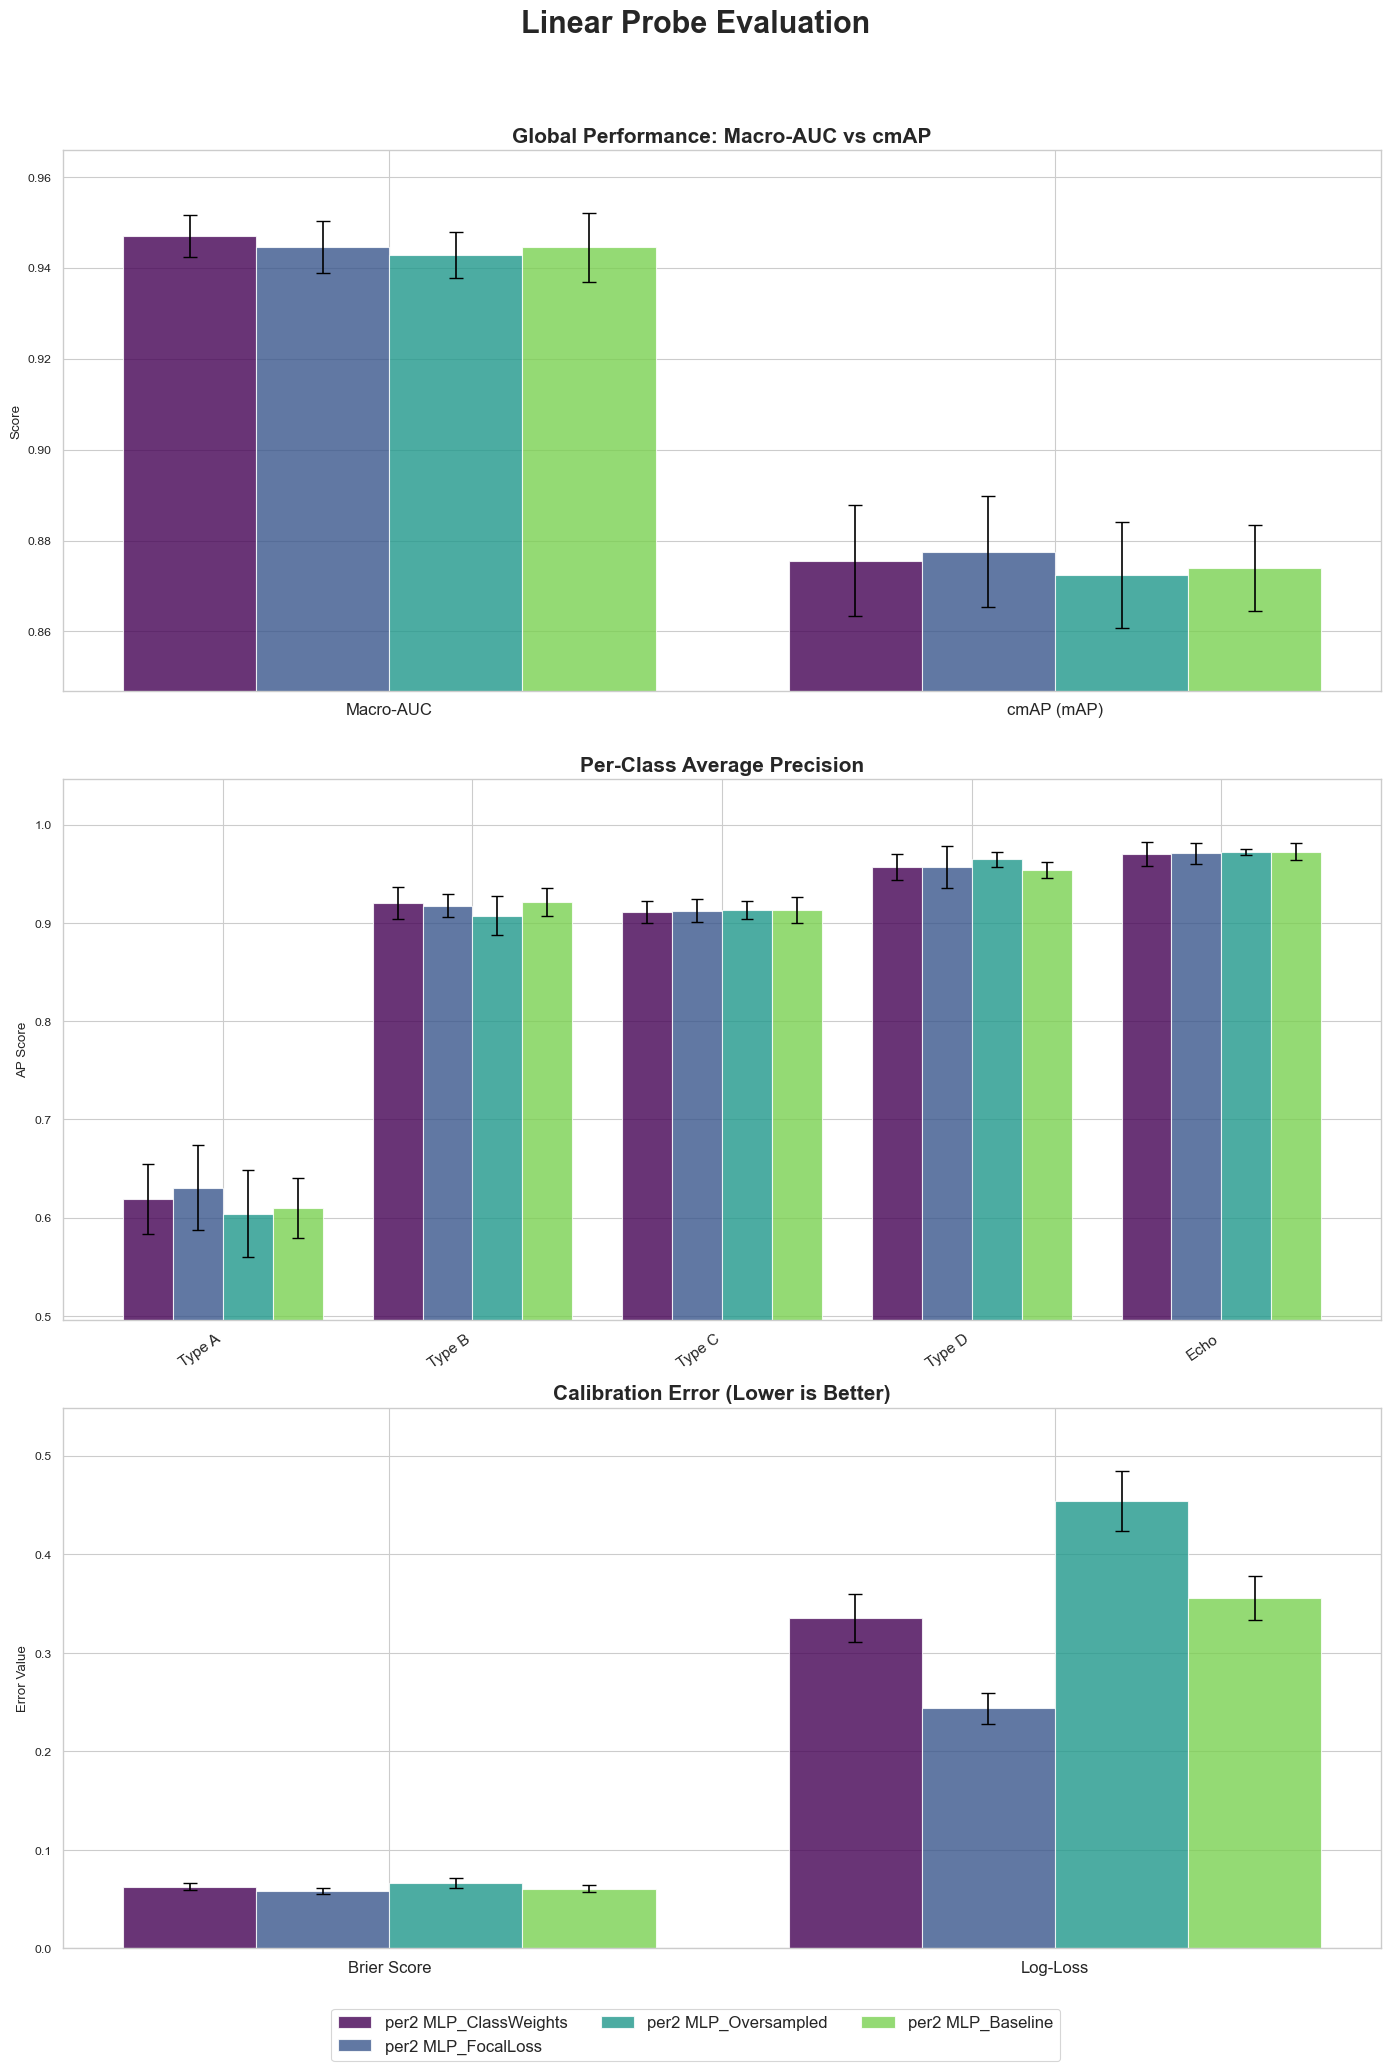

In [25]:
plot_comprehensive_results3(per2_compiled_balanced, labels=label_names, title="Linear Probe Evaluation")

In [ ]:
per2_balancing_val_results = balancing_mlp_val(X_per2_pooled, y, n_split_out=5,n_split_in=5, num_trials=5,random_state=42)

Starting Trial 1/5 with random_state=42...
  Tuning and evaluating model: MLP_Baseline
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: MLP_ClassWeights
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: MLP_FocalLoss
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: MLP_Oversampled
    Evaluating fold 1/5
Final counts: [189 189 202 189 364]
    Evaluating fold 2/5
Final counts: [189 189 230 189 390]
    Evaluating fold 3/5
Final counts: [189 189 216 189 409]
    Evaluating fold 4/5
Final counts: [189 189 238 189 378]
    Evaluating fold 5/5
Final counts: [188 188 195 188 372]
Starting Trial 2/5 with random_state=43...
  Tuning and evaluating model: MLP_Baseline
    Evaluating fold 1/5
  

In [13]:
label_names = ['Type A', 'Type B', 'Type C', 'Type D','Echo']

per2_results_balanced = compile_results(per2_balancing_val_results,label_names=label_names,encoder="per2")

df = pd.DataFrame(generate_metrics_table2(per2_results_balanced,label_names=label_names)[1])
print(tabulate(df, headers='keys', tablefmt='psql'))

+----+-----------------------+---------------+---------------+---------------+---------------+---------------+
|    | Model                 | Type A AP     | Type B AP     | Type C AP     | Type D AP     | Echo AP       |
|----+-----------------------+---------------+---------------+---------------+---------------+---------------|
|  0 | per2 MLP_ClassWeights | 0.612 ± 0.047 | 0.918 ± 0.011 | 0.913 ± 0.006 | 0.956 ± 0.012 | 0.972 ± 0.015 |
|  1 | per2 MLP_FocalLoss    | 0.608 ± 0.045 | 0.918 ± 0.013 | 0.920 ± 0.005 | 0.958 ± 0.014 | 0.971 ± 0.013 |
|  2 | per2 MLP_Oversampled  | 0.604 ± 0.049 | 0.907 ± 0.021 | 0.910 ± 0.013 | 0.949 ± 0.013 | 0.971 ± 0.002 |
|  3 | per2 MLP_Baseline     | 0.599 ± 0.030 | 0.923 ± 0.012 | 0.908 ± 0.013 | 0.955 ± 0.016 | 0.973 ± 0.011 |
+----+-----------------------+---------------+---------------+---------------+---------------+---------------+


In [18]:
df2 = pd.DataFrame(generate_metrics_table2(per2_results_balanced,label_names=label_names)[0])
print(tabulate(df2, headers='keys', tablefmt='psql'))

+----+-----------------------+---------------+-------------------+-----------------+---------------+
|    | Model                 | Macro-AUC     | Macro-AP (cmAP)   | Brier Score ↓   | Log-Loss ↓    |
|----+-----------------------+---------------+-------------------+-----------------+---------------|
|  0 | per2 MLP_ClassWeights | 0.947 ± 0.006 | 0.874 ± 0.014     | 0.063 ± 0.004   | 0.338 ± 0.020 |
|  1 | per2 MLP_FocalLoss    | 0.946 ± 0.005 | 0.875 ± 0.011     | 0.058 ± 0.002   | 0.240 ± 0.013 |
|  2 | per2 MLP_Oversampled  | 0.938 ± 0.008 | 0.868 ± 0.013     | 0.068 ± 0.005   | 0.480 ± 0.032 |
|  3 | per2 MLP_Baseline     | 0.943 ± 0.004 | 0.871 ± 0.008     | 0.061 ± 0.005   | 0.361 ± 0.021 |
+----+-----------------------+---------------+-------------------+-----------------+---------------+


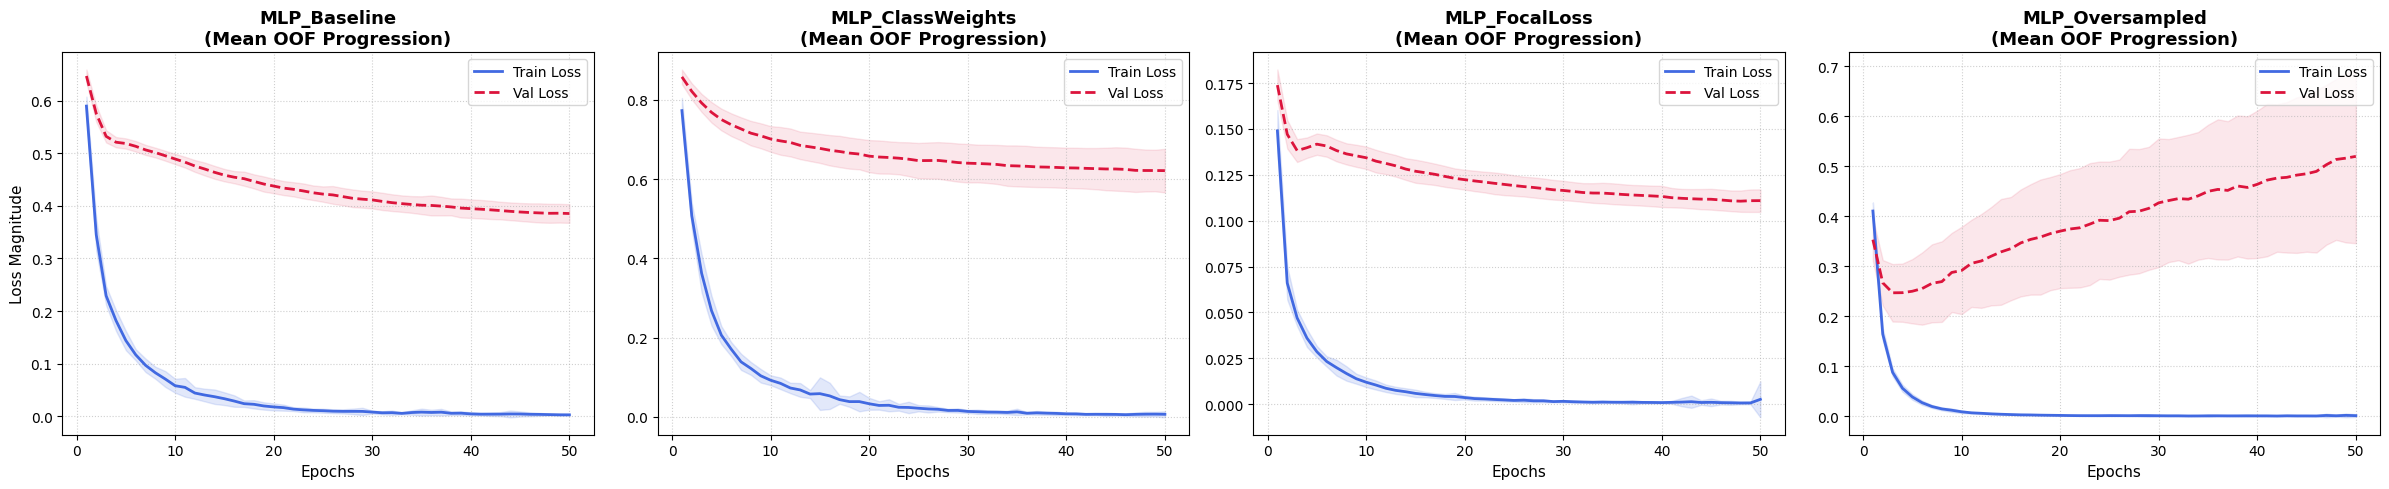

In [14]:
plot_loss_curves(per2_balancing_val_results)

In [15]:
per2_all_results =linear_probe_tuned(X_per2_pooled, y, n_split_out=5,n_split_in=5, num_trials=5,random_state=42)

Starting Trial 1/5 with random_state=42...
  Tuning and evaluating model: SVM
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: Random Forest
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: MLP
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: Prevalence guesser
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
Starting Trial 2/5 with random_state=43...
  Tuning and evaluating model: SVM
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: Random Forest
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3

In [16]:
per2_results = compile_results(per2_all_results,label_names=label_names,encoder="per2")

df = pd.DataFrame(generate_metrics_table2(per2_results,label_names=label_names)[1])
print(tabulate(df, headers='keys', tablefmt='psql'))

+----+-------------------------+---------------+---------------+---------------+---------------+---------------+
|    | Model                   | Type A AP     | Type B AP     | Type C AP     | Type D AP     | Echo AP       |
|----+-------------------------+---------------+---------------+---------------+---------------+---------------|
|  0 | per2 Prevalence guesser | 0.082 ± 0.024 | 0.260 ± 0.032 | 0.546 ± 0.021 | 0.165 ± 0.013 | 0.836 ± 0.024 |
|  1 | per2 MLP                | 0.614 ± 0.041 | 0.916 ± 0.019 | 0.909 ± 0.009 | 0.959 ± 0.017 | 0.973 ± 0.008 |
|  2 | per2 Random Forest      | 0.549 ± 0.035 | 0.834 ± 0.013 | 0.905 ± 0.008 | 0.866 ± 0.008 | 0.978 ± 0.008 |
|  3 | per2 SVM                | 0.510 ± 0.049 | 0.887 ± 0.022 | 0.894 ± 0.027 | 0.963 ± 0.013 | 0.969 ± 0.010 |
+----+-------------------------+---------------+---------------+---------------+---------------+---------------+


In [19]:
df2 = pd.DataFrame(generate_metrics_table2(per2_results,label_names=label_names)[0])
print(tabulate(df2, headers='keys', tablefmt='psql'))

+----+-------------------------+---------------+-------------------+-----------------+---------------+
|    | Model                   | Macro-AUC     | Macro-AP (cmAP)   | Brier Score ↓   | Log-Loss ↓    |
|----+-------------------------+---------------+-------------------+-----------------+---------------|
|  0 | per2 Prevalence guesser | 0.515 ± 0.012 | 0.378 ± 0.008     | 0.159 ± 0.002   | 0.507 ± 0.006 |
|  1 | per2 MLP                | 0.944 ± 0.006 | 0.874 ± 0.013     | 0.059 ± 0.003   | 0.356 ± 0.020 |
|  2 | per2 Random Forest      | 0.920 ± 0.005 | 0.826 ± 0.010     | 0.073 ± 0.001   | 0.269 ± 0.011 |
|  3 | per2 SVM                | 0.934 ± 0.005 | 0.844 ± 0.008     | 0.059 ± 0.002   | 0.221 ± 0.024 |
+----+-------------------------+---------------+-------------------+-----------------+---------------+


In [26]:
NLM_balancing_val_results = balancing_mlp_val(X_NLM_pooled, y, n_split_out=5,n_split_in=5, num_trials=5,random_state=42)

Starting Trial 1/5 with random_state=42...
  Tuning and evaluating model: MLP_Baseline
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: MLP_ClassWeights
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: MLP_FocalLoss
    Evaluating fold 1/5
    Evaluating fold 2/5
    Evaluating fold 3/5
    Evaluating fold 4/5
    Evaluating fold 5/5
  Tuning and evaluating model: MLP_Oversampled
    Evaluating fold 1/5
Final counts: [189 189 202 189 364]
    Evaluating fold 2/5
Final counts: [189 189 230 189 390]
    Evaluating fold 3/5
Final counts: [189 189 216 189 409]
    Evaluating fold 4/5
Final counts: [189 189 238 189 378]
    Evaluating fold 5/5
Final counts: [188 188 195 188 372]
Starting Trial 2/5 with random_state=43...
  Tuning and evaluating model: MLP_Baseline
    Evaluating fold 1/5
  

In [28]:
label_names = ['Type A', 'Type B', 'Type C', 'Type D','Echo']

NLM_compilation_balanced = compile_results(NLM_balancing_val_results,label_names=label_names,encoder="NLM")

df = pd.DataFrame(generate_metrics_table2(NLM_compilation_balanced,label_names=label_names)[1])
print(tabulate(df, headers='keys', tablefmt='psql'))

+----+----------------------+---------------+---------------+---------------+---------------+---------------+
|    | Model                | Type A AP     | Type B AP     | Type C AP     | Type D AP     | Echo AP       |
|----+----------------------+---------------+---------------+---------------+---------------+---------------|
|  0 | NLM MLP_ClassWeights | 0.616 ± 0.034 | 0.901 ± 0.010 | 0.872 ± 0.016 | 0.843 ± 0.019 | 0.974 ± 0.010 |
|  1 | NLM MLP_FocalLoss    | 0.625 ± 0.047 | 0.901 ± 0.014 | 0.869 ± 0.012 | 0.843 ± 0.016 | 0.978 ± 0.006 |
|  2 | NLM MLP_Oversampled  | 0.637 ± 0.031 | 0.882 ± 0.013 | 0.861 ± 0.006 | 0.842 ± 0.013 | 0.973 ± 0.002 |
|  3 | NLM MLP_Baseline     | 0.605 ± 0.033 | 0.889 ± 0.017 | 0.865 ± 0.014 | 0.840 ± 0.015 | 0.971 ± 0.006 |
+----+----------------------+---------------+---------------+---------------+---------------+---------------+


In [29]:
df2 = pd.DataFrame(generate_metrics_table2(NLM_compilation_balanced,label_names=label_names)[0])
print(tabulate(df2, headers='keys', tablefmt='psql'))

+----+----------------------+---------------+-------------------+-----------------+---------------+
|    | Model                | Macro-AUC     | Macro-AP (cmAP)   | Brier Score ↓   | Log-Loss ↓    |
|----+----------------------+---------------+-------------------+-----------------+---------------|
|  0 | NLM MLP_ClassWeights | 0.926 ± 0.009 | 0.841 ± 0.013     | 0.069 ± 0.005   | 0.370 ± 0.038 |
|  1 | NLM MLP_FocalLoss    | 0.925 ± 0.005 | 0.843 ± 0.006     | 0.065 ± 0.003   | 0.275 ± 0.018 |
|  2 | NLM MLP_Oversampled  | 0.916 ± 0.005 | 0.839 ± 0.009     | 0.075 ± 0.006   | 0.557 ± 0.048 |
|  3 | NLM MLP_Baseline     | 0.923 ± 0.010 | 0.834 ± 0.012     | 0.069 ± 0.005   | 0.414 ± 0.031 |
+----+----------------------+---------------+-------------------+-----------------+---------------+


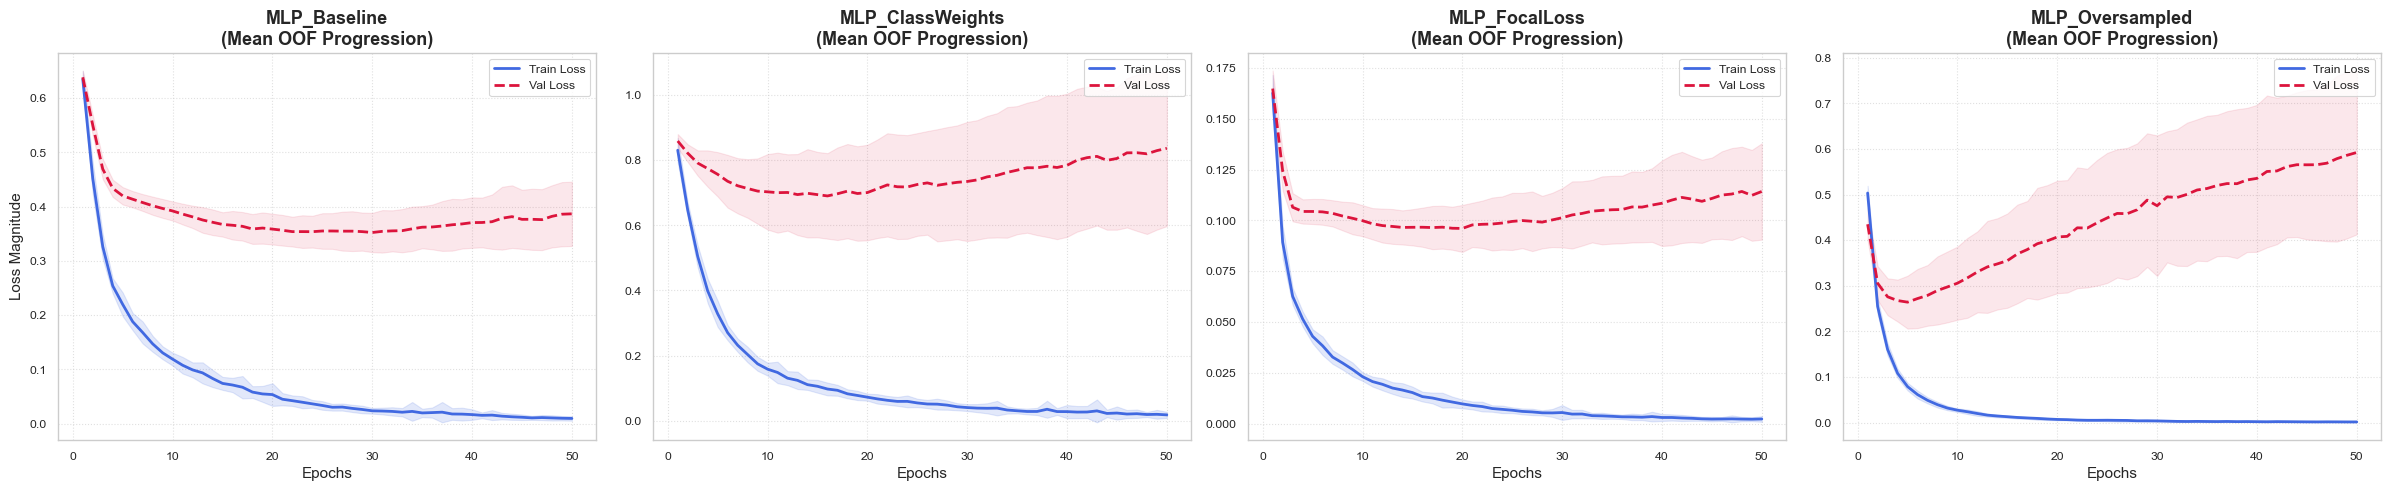

In [30]:
plot_loss_curves(NLM_balancing_val_results)